Import Libraries

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Install & Import

In [ ]:
!pip -q install kagglehub

import os
import tensorflow as tf
import kagglehub

Hyperparameters

In [ ]:
IMG_SIZE = (224,224)

BATCH_SIZE = 32

EPOCHS = 20

LEARNING_RATE = 1e-4

Download Dataset

In [ ]:
path = kagglehub.dataset_download(
    "paultimothymooney/chest-xray-pneumonia"
)

print(path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia


Dataset Paths

In [ ]:
dataset_path = os.path.join(path, "chest_xray")

train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")

Create train_ds, val_ds, and test_ds

In [ ]:
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


Create Class Weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = []

for _, y in train_ds.unbatch():
    labels.append(int(y.numpy()))

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = {
    0: weights[0],
    1: weights[1]
}

print(class_weights)

{0: np.float64(1.9107142857142858), 1: np.float64(0.6772151898734177)}


Apply ResNet50 Preprocessing

In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

train_resnet = train_ds.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_resnet = val_ds.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

test_resnet = test_ds.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.10),

    tf.keras.layers.RandomZoom(0.10)

])

Load Pretrained ResNet50

In [ ]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(

    weights="imagenet",

    include_top=False,

    input_shape=(224,224,3)

)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze Base Model

In [ ]:
base_model.trainable = False

print("Trainable:", base_model.trainable)

Trainable: False


Build Transfer Learning Model

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras import models

model = models.Sequential([

    layers.Input(shape=(224,224,3)),

    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.50),

    layers.Dense(

        256,

        activation="relu"

    ),

    layers.Dropout(0.30),

    layers.Dense(

        128,

        activation="relu"

    ),

    layers.Dropout(0.20),

    layers.Dense(

        1,

        activation="sigmoid"

    )

])

Model Summary

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,145,281 (92.11 MB)

 Trainable params: 557,569 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Compile Model

In [ ]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=LEARNING_RATE

    ),

    loss="binary_crossentropy",

    metrics=[

        "accuracy",

        tf.keras.metrics.Precision(name="precision"),

        tf.keras.metrics.Recall(name="recall"),

        tf.keras.metrics.AUC(name="auc")

    ]

)

Callbacks

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

checkpoint = ModelCheckpoint(

    "best_resnet50.keras",

    monitor="val_loss",

    save_best_only=True,

    mode="min",

    verbose=1

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    min_lr=1e-6,

    verbose=1

)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True,

    verbose=1

)

callbacks = [

    checkpoint,

    reduce_lr,

    early_stop

]

Train Model

In [ ]:
history = model.fit(

    train_resnet,

    validation_data=val_resnet,

    epochs=EPOCHS,

    class_weight=class_weights,

    callbacks=callbacks

)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.6231 - auc: 0.6872 - loss: 0.6936 - precision: 0.8246 - recall: 0.6124
Epoch 1: val_loss improved from None to 0.28281, saving model to best_resnet50.keras

Epoch 1: finished saving model to best_resnet50.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 64s 364ms/step - accuracy: 0.7261 - auc: 0.8149 - loss: 0.5317 - precision: 0.8904 - recall: 0.7173 - val_accuracy: 0.8907 - val_auc: 0.9761 - val_loss: 0.2828 - val_precision: 0.9942 - val_recall: 0.8615 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.8541 - auc: 0.9306 - loss: 0.3386 - precision: 0.9463 - recall: 0.8483
Epoch 2: val_loss improved from 0.28281 to 0.20755, saving model to best_resnet50.keras

Epoch 2: finished saving model to best_resnet50.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 44s 338ms/step - accuracy: 0.8680 - auc: 0.9373 - loss: 0.3202 - precision: 0.9499 - recall: 0.8669 - val_accuracy: 0.9243 - val_auc: 0.9793 - val_l

Unfreeze the Last 30 Layers

In [ ]:
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Trainable Layers:")
for layer in base_model.layers[-30:]:
    print(layer.name, layer.trainable)

Trainable Layers:
conv5_block1_1_relu True
conv5_block1_2_conv True
conv5_block1_2_bn True
conv5_block1_2_relu True
conv5_block1_0_conv True
conv5_block1_3_conv True
conv5_block1_0_bn True
conv5_block1_3_bn True
conv5_block1_add True
conv5_block1_out True
conv5_block2_1_conv True
conv5_block2_1_bn True
conv5_block2_1_relu True
conv5_block2_2_conv True
conv5_block2_2_bn True
conv5_block2_2_relu True
conv5_block2_3_conv True
conv5_block2_3_bn True
conv5_block2_add True
conv5_block2_out True
conv5_block3_1_conv True
conv5_block3_1_bn True
conv5_block3_1_relu True
conv5_block3_2_conv True
conv5_block3_2_bn True
conv5_block3_2_relu True
conv5_block3_3_conv True
conv5_block3_3_bn True
conv5_block3_add True
conv5_block3_out True


Recompile with a Lower Learning Rate

In [ ]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

Fine-Tune the Model

In [ ]:
history_finetune = model.fit(

    train_resnet,

    validation_data=val_resnet,

    epochs=10,

    class_weight=class_weights,

    callbacks=callbacks,

    verbose=1

)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.6132 - auc: 0.6076 - loss: 0.7165 - precision: 0.7788 - recall: 0.6632
Epoch 1: val_loss improved from None to 0.28210, saving model to best_resnet50.keras

Epoch 1: finished saving model to best_resnet50.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 68s 365ms/step - accuracy: 0.6928 - auc: 0.7538 - loss: 0.5848 - precision: 0.8521 - recall: 0.7066 - val_accuracy: 0.9022 - val_auc: 0.9750 - val_loss: 0.2821 - val_precision: 0.9806 - val_recall: 0.8892 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.8596 - auc: 0.9410 - loss: 0.3473 - precision: 0.9613 - recall: 0.8421
Epoch 2: val_loss improved from 0.28210 to 0.18410, saving model to best_resnet50.keras

Epoch 2: finished saving model to best_resnet50.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 47s 358ms/step - accuracy: 0.8749 - auc: 0.9511 - loss: 0.3107 - precision: 0.9641 - recall: 0.8627 - val_accuracy: 0.9233 - val_auc: 0.9844 - val_l

Load the Best Model

In [ ]:
best_model = tf.keras.models.load_model("best_resnet50.keras")

Evaluate on Test Dataset

In [ ]:
loss, accuracy, precision, recall, auc_score = best_model.evaluate(test_resnet)

print("="*40)
print(f"Test Accuracy  : {accuracy:.4f}")
print(f"Test Precision : {precision:.4f}")
print(f"Test Recall    : {recall:.4f}")
print(f"Test AUC       : {auc_score:.4f}")
print(f"Test Loss      : {loss:.4f}")
print("="*40)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 302ms/step - accuracy: 0.8542 - auc: 0.9492 - loss: 0.4911 - precision: 0.8201 - recall: 0.9821
Test Accuracy  : 0.8542
Test Precision : 0.8201
Test Recall    : 0.9821
Test AUC       : 0.9492
Test Loss      : 0.4911


Predict Test Images

In [ ]:
import numpy as np

y_true = np.concatenate(
    [labels.numpy() for images, labels in test_resnet]
)

y_prob = best_model.predict(test_resnet)

y_pred = (y_prob > 0.5).astype(int).flatten()

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 226ms/step


Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(

    y_true,

    y_pred,

    target_names=[
        "NORMAL",
        "PNEUMONIA"
    ]

))

              precision    recall  f1-score   support

      NORMAL       0.96      0.64      0.77       234
   PNEUMONIA       0.82      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.81      0.83       624
weighted avg       0.87      0.85      0.85       624



Confusion Matrix

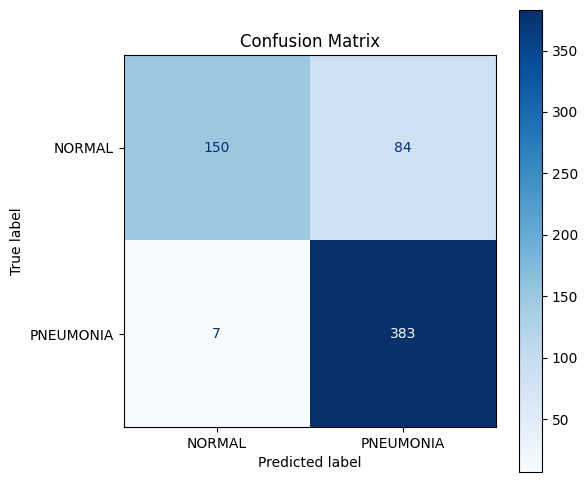

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[
        "NORMAL",
        "PNEUMONIA"
    ]

)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(

    cmap="Blues",

    values_format="d",

    ax=ax

)

plt.title("Confusion Matrix")

plt.show()

ROC Curve

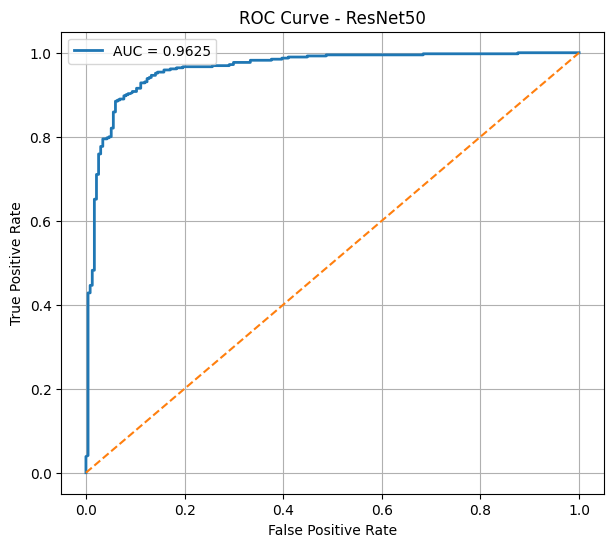

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1], [0,1], "--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - ResNet50")

plt.grid(True)

plt.legend()

plt.show()

Accuracy Graph

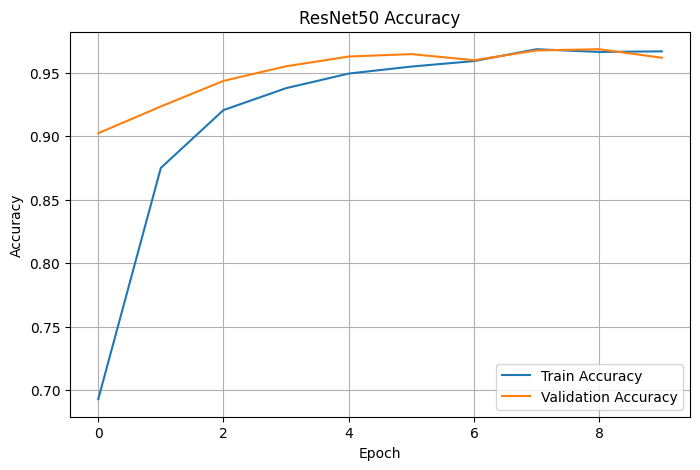

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_finetune.history['accuracy'], label='Train Accuracy')

plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("ResNet50 Accuracy")

plt.grid(True)

plt.legend()

plt.show()

Loss Graph

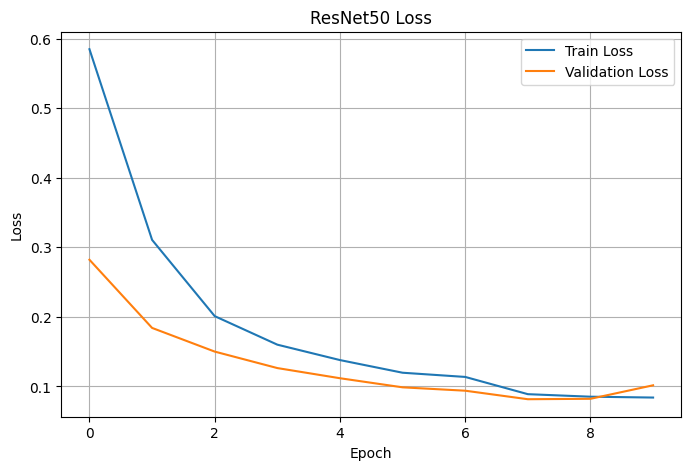

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_finetune.history['loss'], label='Train Loss')

plt.plot(history_finetune.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("ResNet50 Loss")

plt.grid(True)

plt.legend()

plt.show()

Save Final Model

In [ ]:
best_model.save("ResNet50_Final_Model.keras")

print("✅ ResNet50 Model Saved Successfully")

✅ ResNet50 Model Saved Successfully


Training Summary

In [ ]:
print("="*50)

print("Transfer Learning - ResNet50")

print("="*50)

print("Epochs Trained :", len(history_finetune.history['loss']))

print("Best Training Accuracy :", max(history_finetune.history['accuracy']))

print("Best Validation Accuracy :", max(history_finetune.history['val_accuracy']))

print("Lowest Validation Loss :", min(history_finetune.history['val_loss']))

print("="*50)

Transfer Learning - ResNet50
Epochs Trained : 10
Best Training Accuracy : 0.9683680534362793
Best Validation Accuracy : 0.9683604836463928
Lowest Validation Loss : 0.08159223943948746


In [ ]:
import os

print(os.listdir())

['.config', 'ResNet50_Final_Model.keras', 'best_resnet50.keras', 'sample_data']


In [ ]:
from google.colab import files

files.download("ResNet50_Final_Model.zip")

FileNotFoundError: Cannot find file: ResNet50_Final_Model.zip